In [27]:
from random import shuffle

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [28]:
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target



In [29]:
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle = True,
    random_state=42,
    stratify=y
)

In [30]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
model = KNeighborsClassifier(
    n_neighbors=5,
    p=2,
    metric='minkowski',
    weights='uniform',
    algorithm='auto',
    n_jobs=-1,
    leaf_size=30,

)
model.fit(X_train , y_train)
y_pred = model.predict(X_test)

In [32]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision :", precision_score(y_test, y_pred))

print("Recall :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.956140350877193
Precision : 0.958904109589041
Recall : 0.9722222222222222
F1 Score : 0.9655172413793104


In [33]:
print(confusion_matrix(y_test, y_pred))

[[39  3]
 [ 2 70]]


In [34]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



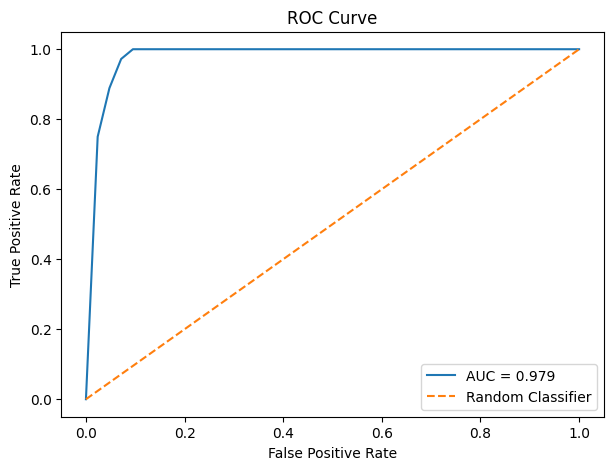

In [35]:
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score

# Probability of the positive class
y_prob = model.predict_proba(X_test)[:, 1]

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## **KNN Regressor**

In [36]:
from sklearn.datasets import load_diabetes

from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [37]:
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [40]:
model = KNeighborsRegressor(
    n_neighbors=5,
    weights='uniform',
    metric='minkowski',
    p = 2,
    algorithm='auto',
    n_jobs=-1
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [41]:
print("MAE :", mean_absolute_error(y_test, predictions))

print("MSE :", mean_squared_error(y_test, predictions))

print("RMSE :", np.sqrt(mean_squared_error(y_test, predictions)))

print("R² :", r2_score(y_test, predictions))

MAE : 42.777528089887646
MSE : 3047.449887640449
RMSE : 55.203712625515045
R² : 0.42480887066066253
